In [93]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *
import emcee
from functools import partial
import time

figures_dir = '/u8/d/len/code/radjax_updated/figures/'
radmc_dir = '/u8/d/len/code/radmc3d-2.0/src/'
units_to_cm = au * 100.0

In [1]:
!nvidia-smi

Thu Jun 19 07:45:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.67                 Driver Version: 550.67         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:4F:00.0 Off |                  Off |
| 30%   19C    P8             16W /  300W |     412MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
# Read the command string from make_img.sh
with open(f'{radmc_dir}/make_img.sh', 'r') as f:
    cmd_line = f.read().strip()
    print(cmd_line)

# Safety: handle multiple lines with '\'
cmd_line = cmd_line.replace('\\', ' ')

tokens = cmd_line.split()
keys = ['incl', 'phi', 'npix', 'posang', 'imolspec', 'iline', 'widthkms', 'linenlam']

params = {}

i = 0
while i < len(tokens):
    token = tokens[i]
    if token in keys:
        val = tokens[i+1]
        if '.' in val or 'e' in val.lower():
            val = float(val)
        else:
            val = int(val)
        params[token] = val
        i += 1 
    i += 1

# flags
flags = {'doppcatch': 'doppcatch' in tokens,
         'noscat': 'noscat' in tokens,
         'secondorder': 'secondorder' in tokens}

# Print result
print("Params:", params)
print("Flags:", flags)


radmc3d image incl 45.0 phi 100.0 npix 384 posang 0.0 imolspec 1 iline 3 widthkms 3.65 linenlam 50 doppcatch noscat secondorder
Params: {'incl': 45.0, 'phi': 100.0, 'npix': 384, 'posang': 0.0, 'imolspec': 1, 'iline': 3, 'widthkms': 3.65, 'linenlam': 50}
Flags: {'doppcatch': True, 'noscat': True, 'secondorder': True}


In [25]:
from consts import *

# Read wavelength_micron.inp
with open(f'{radmc_dir}/wavelength_micron.inp', 'r') as f:
    nlam = int(f.readline())
    wavelengths_micron = []
    for _ in range(nlam):
        wavelengths_micron.append(float(f.readline()))

# Convert to cm
wavelengths_cm = np.array(wavelengths_micron) * 1e-4

# Compute frequency [Hz]
freqs = cc / wavelengths_cm

# Print result
print(f"Wavelengths (micron): {wavelengths_micron}")
print(f"Frequencies (Hz): {freqs}")

linenlam = params['linenlam']
width_kms = params['widthkms']
nu0 = freqs[0]
v_sys = 0.0

camera_freqs = sensor.compute_camera_freqs(linenlam, width_kms, nu0, v_sys)
print(camera_freqs)

Wavelengths (micron): [866.963446]
Frequencies (Hz): [3.45795961e+11]
[3.45800171e+11 3.45799999e+11 3.45799827e+11 3.45799656e+11
 3.45799484e+11 3.45799312e+11 3.45799140e+11 3.45798968e+11
 3.45798796e+11 3.45798625e+11 3.45798453e+11 3.45798281e+11
 3.45798109e+11 3.45797937e+11 3.45797765e+11 3.45797594e+11
 3.45797422e+11 3.45797250e+11 3.45797078e+11 3.45796906e+11
 3.45796734e+11 3.45796562e+11 3.45796391e+11 3.45796219e+11
 3.45796047e+11 3.45795875e+11 3.45795703e+11 3.45795531e+11
 3.45795360e+11 3.45795188e+11 3.45795016e+11 3.45794844e+11
 3.45794672e+11 3.45794500e+11 3.45794329e+11 3.45794157e+11
 3.45793985e+11 3.45793813e+11 3.45793641e+11 3.45793469e+11
 3.45793298e+11 3.45793126e+11 3.45792954e+11 3.45792782e+11
 3.45792610e+11 3.45792438e+11 3.45792266e+11 3.45792095e+11
 3.45791923e+11 3.45791751e+11]


In [26]:
r, theta, phi = grid.read_spherical_amr(f'{radmc_dir}/amr_grid.inp')
phi_min, phi_max = phi[0], phi[-1]
theta_min, theta_max = theta[0], theta[-1]
r_min, r_max = r[0], r[-1]

# Bounding box for interpolations (logarithmic r scale)w
bbox = jnp.array([(phi_min, phi_max), (theta_min, theta_max), (np.log10(r_min), np.log10(r_max))])
fov = np.float32(1.1) * 2*r[-1]  # Note: float32 is to match radmc3d exact pixel grid
pixel_area = (fov/params['npix'])**2       # pixel area to convert radiances to Jy 

nray = 100

ray_coords, obs_dir = sensor.orthographic_disk_projection(params['npix'], nray, params['incl'], params['phi'], params['posang'], fov, r_min, r_max, theta_min, theta_max)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)

In [27]:
with open(f'{radmc_dir}/gas_temperature.inp', 'r') as f:
    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())
    ndim = int(f.readline())
    assert ndim == 1, "Only 1D scalar field supported"

    # Read remaining lines
    data = []
    while len(data) < nrcells:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# reshape to 3D grid
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

# Fortran order (slowest varying ix, then iy, then iz) -> reshape:
# Original reshape is (r, theta, phi): (nx, ny, nz) → after transpose(2,1,0): (nx, ny, nz)
# To get (phi, theta, r), we reshape as (nz, ny, nx) and no transpose needed:
gas_temperature = data.reshape((nz, ny, nx))

# Now gas_temperature[phi, theta, r] gives the temperature
print(gas_temperature.shape)   # should be (512, 96, 256) → (phi, theta, r)


(512, 96, 256)


In [28]:
import numpy as np

with open(f'{radmc_dir}/gas_velocity.inp', 'r') as f:

    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())

    data = []
    while len(data) < nrcells * 3:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# Reshape into (nrcells, 3)
data = data.reshape((nrcells, 3))

# Reshape to (phi, theta, r, vector)
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

gas_velocity = data.reshape((nz, ny, nx, 3)).transpose(0,1,2,3)

# Now gas_velocity[phi, theta, r, vector]
print(gas_velocity.shape)  # should be (512, 96, 256, 3)

(512, 96, 256, 3)


In [29]:
import numpy as np

with open(f'{radmc_dir}/numberdens_12c16o.inp', 'r') as f:

    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())

    data = []
    while len(data) < nrcells:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# Reshape to (nz, ny, nx) → (phi, theta, r)
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

numberdens_12c16o = data.reshape((nz, ny, nx))

# Now numberdens_12c16o[phi, theta, r]
print(numberdens_12c16o.shape)  # should be (512, 96, 256)


(512, 96, 256)


In [30]:
import numpy as np

with open(f'{radmc_dir}/numberdens_h2.inp', 'r') as f:

    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())

    data = []
    while len(data) < nrcells:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# Reshape to (nz, ny, nx) → (phi, theta, r)
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

numberdens_h2 = data.reshape((nz, ny, nx))

# Now numberdens_h2[phi, theta, r]
print(numberdens_h2.shape)  # should be (512, 96, 256)


(512, 96, 256)


In [31]:
# Interpolate dataset along the (spherical) ray coordinates
# ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
gas_nd = grid.interpolate_scalar(numberdens_12c16o, ray_coords_sph, bbox)
gas_t  = grid.interpolate_scalar(gas_temperature, ray_coords_sph, bbox, cval=1e-10)

# Einstein coefficient for spontaneous emission from level u to level d
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=f'{radmc_dir}/molecule_12c16o.inp')
nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)
n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
print('line frequency: {} Ghz'.format(nu0/ghz))

line frequency: 345.7959899 Ghz


In [32]:
gas_v = grid.interpolate_vector(gas_velocity, ray_coords, ray_coords_sph, bbox)
alpha_tot = line_rte.alpha_total_co(0, gas_t)

images = line_rte.compute_spectral_cube_pmap(
        shard(camera_freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
images_radjax = np.nan_to_num(images).reshape(params['linenlam'], params['npix'], params['npix'])
    
# # Define a parallel mapping over several gpus
# pmap = jax.pmap(line_rte.compute_spectral_cube,
#                 axis_name='freq', 
#                 in_axes=(0, None, None, None, None, None, None, None, None, None, None, None))

# print('computing spectral cube for a total of {} frequencies'.format(camera_freqs.size))
# images = pmap(shard(camera_freqs), gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area)
# images = np.nan_to_num(images).reshape(params['linenlam'], params['npix'], params['npix'])

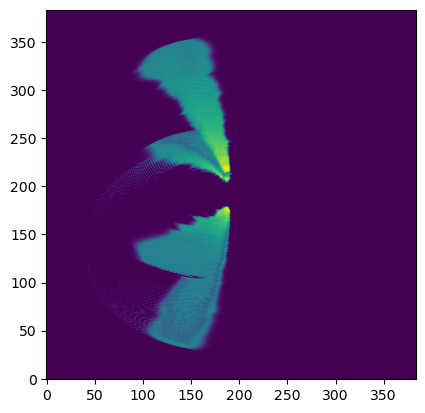

In [33]:
plt.imshow(images_radjax[21], origin='lower')

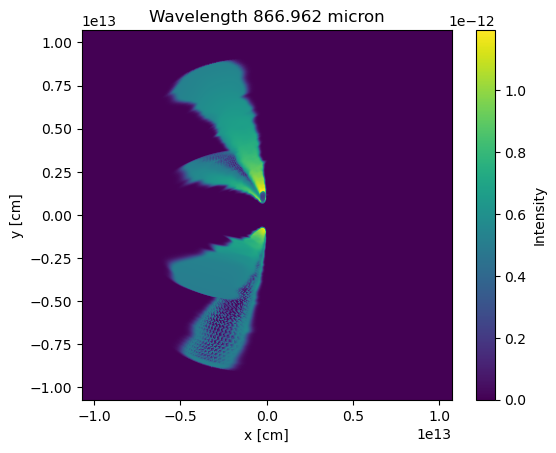

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Read entire file once
with open(f'{radmc_dir}/image.out', 'r') as f:
    lines = f.readlines()

# Header parsing
fmt = int(lines[0])
assert fmt == 1, f"Unexpected format: {fmt}"

parts = lines[1].split()
if len(parts) == 3:
    nx, ny, nlam = map(int, parts)
    size_line_idx = 3
    wav_start_line = 4
elif len(parts) == 2:
    nx, ny = map(int, parts)
    nlam = int(lines[2])
    size_line_idx = 3
    wav_start_line = 4
else:
    raise ValueError(f"Unexpected number of values in line 2: {parts}")

# Image size
size_x, size_y = map(float, lines[size_line_idx].split())

# Wavelengths — fast with np.loadtxt
wav = np.loadtxt(f'{radmc_dir}/image.out', skiprows=wav_start_line, max_rows=nlam)

# Image data — also fast with np.loadtxt
data_start_line = wav_start_line + nlam
flat_data = np.loadtxt(f'{radmc_dir}/image.out', skiprows=data_start_line)

# Reshape to cube
images_radmc3d = flat_data.reshape((nlam, ny, nx))

# Plot one image
idx = 21
plt.imshow(images_radmc3d[idx], origin='lower', extent=[-size_x/2, size_x/2, -size_y/2, size_y/2])
plt.colorbar(label='Intensity')
plt.title(f"Wavelength {wav[idx]:.3f} micron")
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')
plt.show()


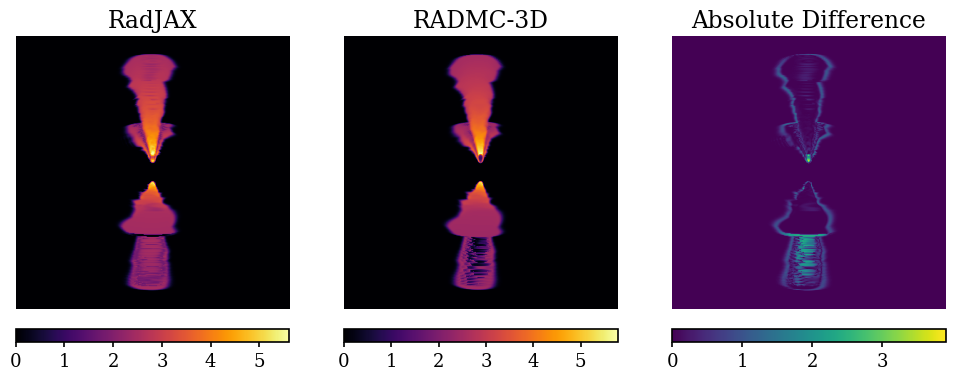

In [127]:
idx = 24  # e.g. plot channel 10

# Extract images
img_radjax = images_radjax[idx]
img_radmc3d = (fov / params['npix'])**2 / pc**2 * 1e23 * images_radmc3d[idx]
residual_abs = np.abs(img_radjax - img_radmc3d)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# RadJAX image
im0 = axes[0].imshow(img_radjax, cmap='inferno', origin='lower')
axes[0].set_title('RadJAX')
axes[0].axis('off')
cbar0 = plt.colorbar(im0, ax=axes[0], orientation='horizontal', fraction=0.05, pad=0.05)
vmin0, vmax0 = im0.get_clim()
cbar0.set_ticks(np.arange(0, np.ceil(vmax0), 1))

# RadMC-3D image
im1 = axes[1].imshow(img_radmc3d, cmap='inferno', origin='lower')
axes[1].set_title('RADMC-3D')
axes[1].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[1], orientation='horizontal', fraction=0.05, pad=0.05)
vmin1, vmax1 = im1.get_clim()
cbar1.set_ticks(np.arange(0, np.ceil(vmax1), 1))

# Residual image
im2 = axes[2].imshow(residual_abs, cmap='viridis', origin='lower')
axes[2].set_title('Absolute Difference')
axes[2].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[2], orientation='horizontal', fraction=0.05, pad=0.05)
vmin2, vmax2 = im2.get_clim()
cbar2.set_ticks(np.arange(0, np.ceil(vmax2), 1))

plt.savefig(f'{figures_dir}render_comparison_channel24.svg', format='svg', dpi=400, bbox_inches='tight')
plt.show()

# Run time benchmark
## Read input fields

In [39]:
# Read the command string from make_img.sh
with open(f'{radmc_dir}/make_img.sh', 'r') as f:
    cmd_line = f.read().strip()
    print(cmd_line)

# Safety: handle multiple lines with '\'
cmd_line = cmd_line.replace('\\', ' ')

tokens = cmd_line.split()
keys = ['incl', 'phi', 'npix', 'posang', 'imolspec', 'iline', 'widthkms', 'linenlam']

params = {}

i = 0
while i < len(tokens):
    token = tokens[i]
    if token in keys:
        val = tokens[i+1]
        if '.' in val or 'e' in val.lower():
            val = float(val)
        else:
            val = int(val)
        params[token] = val
        i += 1 
    i += 1

# flags
flags = {'doppcatch': 'doppcatch' in tokens,
         'noscat': 'noscat' in tokens,
         'secondorder': 'secondorder' in tokens}

# Print result
print("Params:", params)
print("Flags:", flags)

from consts import *

# Read wavelength_micron.inp
with open(f'{radmc_dir}/wavelength_micron.inp', 'r') as f:
    nlam = int(f.readline())
    wavelengths_micron = []
    for _ in range(nlam):
        wavelengths_micron.append(float(f.readline()))

# Convert to cm
wavelengths_cm = np.array(wavelengths_micron) * 1e-4

# Compute frequency [Hz]
freqs = cc / wavelengths_cm

# Print result
print(f"Wavelengths (micron): {wavelengths_micron}")
print(f"Frequencies (Hz): {freqs}")

linenlam = params['linenlam']
width_kms = params['widthkms']
nu0 = freqs[0]
v_sys = 0.0

with open(f'{radmc_dir}/gas_temperature.inp', 'r') as f:
    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())
    ndim = int(f.readline())
    assert ndim == 1, "Only 1D scalar field supported"

    # Read remaining lines
    data = []
    while len(data) < nrcells:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# reshape to 3D grid
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

# Fortran order (slowest varying ix, then iy, then iz) -> reshape:
# Original reshape is (r, theta, phi): (nx, ny, nz) → after transpose(2,1,0): (nx, ny, nz)
# To get (phi, theta, r), we reshape as (nz, ny, nx) and no transpose needed:
gas_temperature = data.reshape((nz, ny, nx))

# Now gas_temperature[phi, theta, r] gives the temperature
print(gas_temperature.shape)   # should be (512, 96, 256) → (phi, theta, r)


import numpy as np

with open(f'{radmc_dir}/gas_velocity.inp', 'r') as f:

    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())

    data = []
    while len(data) < nrcells * 3:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# Reshape into (nrcells, 3)
data = data.reshape((nrcells, 3))

# Reshape to (phi, theta, r, vector)
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

gas_velocity = data.reshape((nz, ny, nx, 3)).transpose(0,1,2,3)

# Now gas_velocity[phi, theta, r, vector]
print(gas_velocity.shape)  # should be (512, 96, 256, 3)

import numpy as np

with open(f'{radmc_dir}/numberdens_12c16o.inp', 'r') as f:

    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())

    data = []
    while len(data) < nrcells:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# Reshape to (nz, ny, nx) → (phi, theta, r)
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

numberdens_12c16o = data.reshape((nz, ny, nx))

# Now numberdens_12c16o[phi, theta, r]
print(numberdens_12c16o.shape)  # should be (512, 96, 256)


import numpy as np

with open(f'{radmc_dir}/numberdens_h2.inp', 'r') as f:

    fmt = int(f.readline())
    assert fmt == 1, "Only format 1 supported"

    nrcells = int(f.readline())

    data = []
    while len(data) < nrcells:
        line = f.readline()
        data.extend(map(float, line.strip().split()))

    data = np.array(data)

# Reshape to (nz, ny, nx) → (phi, theta, r)
nx, ny, nz = 256, 96, 512
assert nrcells == nx * ny * nz

numberdens_h2 = data.reshape((nz, ny, nx))

# Now numberdens_h2[phi, theta, r]
print(numberdens_h2.shape)  # should be (512, 96, 256)

r, theta, phi = grid.read_spherical_amr(f'{radmc_dir}/amr_grid.inp')
phi_min, phi_max = phi[0], phi[-1]
theta_min, theta_max = theta[0], theta[-1]
r_min, r_max = r[0], r[-1]

radmc3d image incl 45.0 phi 100.0 npix 384 posang 0.0 imolspec 1 iline 3 widthkms 3.65 linenlam 50 doppcatch noscat secondorder
Params: {'incl': 45.0, 'phi': 100.0, 'npix': 384, 'posang': 0.0, 'imolspec': 1, 'iline': 3, 'widthkms': 3.65, 'linenlam': 50}
Flags: {'doppcatch': True, 'noscat': True, 'secondorder': True}
Wavelengths (micron): [866.963446]
Frequencies (Hz): [3.45795961e+11]
(512, 96, 256)
(512, 96, 256, 3)
(512, 96, 256)
(512, 96, 256)


In [16]:
# linenlam = params['linenlam']
# npix = params['npix']


linenlam = 10
npix = 256

camera_freqs = sensor.compute_camera_freqs(linenlam, width_kms, nu0, v_sys)
print(camera_freqs)

r, theta, phi = grid.read_spherical_amr(f'{radmc_dir}/amr_grid.inp')
phi_min, phi_max = phi[0], phi[-1]
theta_min, theta_max = theta[0], theta[-1]
r_min, r_max = r[0], r[-1]

# Bounding box for interpolations (logarithmic r scale)w
bbox = jnp.array([(phi_min, phi_max), (theta_min, theta_max), (np.log10(r_min), np.log10(r_max))])
fov = np.float32(1.1) * 2*r[-1]  # Note: float32 is to match radmc3d exact pixel grid
pixel_area = (fov/npix)**2       # pixel area to convert radiances to Jy 

nray = 100

ray_coords, obs_dir = sensor.orthographic_disk_projection(npix, nray, params['incl'], params['phi'], params['posang'], fov, r_min, r_max, theta_min, theta_max)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)

# Interpolate dataset along the (spherical) ray coordinates
# ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
gas_nd = grid.interpolate_scalar(numberdens_12c16o, ray_coords_sph, bbox)
gas_t  = grid.interpolate_scalar(gas_temperature, ray_coords_sph, bbox, cval=1e-10)

# Einstein coefficient for spontaneous emission from level u to level d
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=f'{radmc_dir}/molecule_12c16o.inp')
nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)
n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
print('line frequency: {} Ghz'.format(nu0/ghz))

gas_v = grid.interpolate_vector(gas_velocity, ray_coords, ray_coords_sph, bbox)
alpha_tot = line_rte.alpha_total_co(0, gas_t)

[3.45800171e+11 3.45799236e+11 3.45798300e+11 3.45797364e+11
 3.45796429e+11 3.45795493e+11 3.45794558e+11 3.45793622e+11
 3.45792687e+11 3.45791751e+11]
line frequency: 345.7959899 Ghz


In [20]:
# Time how long this takes for each configuration of linenlam and npix

images_benchmark = line_rte.compute_spectral_cube_pmap(
        shard(camera_freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )

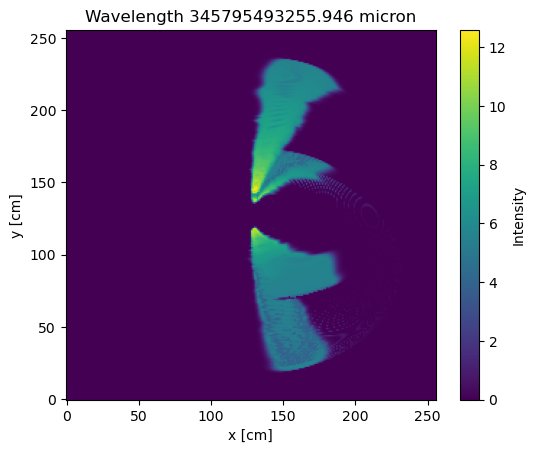

In [21]:
idx = 5
plt.imshow(np.nan_to_num(images_benchmark).reshape(linenlam,npix,npix)[idx], origin='lower')
plt.colorbar(label='Intensity')
plt.title(f"Wavelength {camera_freqs[idx]:.3f} micron")
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')
plt.show()

In [42]:
import numpy as np
import time

n_runs = 50

npix_values = [64, 128, 256, 384, 512, 640]
linenlam_values = [2, 10, 20, 30, 40, 50]

# Init arrays to store times:
times_stage1 = np.zeros((n_runs, len(npix_values)))
times_stage2 = np.zeros((n_runs, len(linenlam_values)))

# Fixed params for Ray / Camera
fov_base = np.float32(1.1) * 2*r[-1]
r_min, r_max = r[0], r[-1]
theta_min, theta_max = theta[0], theta[-1]
phi_min, phi_max = phi[0], phi[-1]
bbox = jnp.array([(phi_min, phi_max), (theta_min, theta_max), (jnp.log10(r_min), jnp.log10(r_max))])
nray = 100

# Load molecule tables once
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=f'{radmc_dir}/molecule_12c16o.inp')
nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)


In [ ]:
### PART 1: Vary npix, linenlam=20 ###
linenlam = 20
print(f"##### Stage 1: Varying npix with fixed linenlam={linenlam} #####")

for npix_idx, npix in enumerate(npix_values):
    print(f"===== npix={npix} =====")
    
    for run_idx in range(n_runs):
        camera_freqs = sensor.compute_camera_freqs(linenlam, width_kms, nu0, v_sys)
        pixel_area = (fov_base/npix)**2
        
        ray_coords, obs_dir = sensor.orthographic_disk_projection(
            npix, nray, params['incl'], params['phi'], params['posang'],
            fov_base, r_min, r_max, theta_min, theta_max
        )
        ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)
        
        gas_nd = grid.interpolate_scalar(numberdens_12c16o, ray_coords_sph, bbox)
        gas_t  = grid.interpolate_scalar(gas_temperature, ray_coords_sph, bbox, cval=1e-10)
        
        n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
        gas_v = grid.interpolate_vector(gas_velocity, ray_coords, ray_coords_sph, bbox)
        alpha_tot = line_rte.alpha_total_co(0, gas_t)
        
        start_time = time.time()
        images = line_rte.compute_spectral_cube_pmap(
            shard(camera_freqs), gas_v, alpha_tot, n_up, n_dn,
            a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
        )
        jax.block_until_ready(images)
        elapsed_time = time.time() - start_time
        
        print(f"Run {run_idx+1}: npix={npix}, linenlam={linenlam}, time={elapsed_time:.3f} sec")
        times_stage1[run_idx, npix_idx] = elapsed_time


### PART 2: Vary linenlam, npix=256 ###
npix = 256
print(f"##### Stage 2: Varying linenlam with fixed npix={npix} #####")

for linenlam_idx, linenlam in enumerate(linenlam_values):
    print(f"===== linenlam={linenlam} =====")
    
    for run_idx in range(n_runs):
        camera_freqs = sensor.compute_camera_freqs(linenlam, width_kms, nu0, v_sys)
        pixel_area = (fov_base/npix)**2
        
        ray_coords, obs_dir = sensor.orthographic_disk_projection(
            npix, nray, params['incl'], params['phi'], params['posang'],
            fov_base, r_min, r_max, theta_min, theta_max
        )
        ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)
        
        gas_nd = grid.interpolate_scalar(numberdens_12c16o, ray_coords_sph, bbox)
        gas_t  = grid.interpolate_scalar(gas_temperature, ray_coords_sph, bbox, cval=1e-10)
        
        n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
        gas_v = grid.interpolate_vector(gas_velocity, ray_coords, ray_coords_sph, bbox)
        alpha_tot = line_rte.alpha_total_co(0, gas_t)
        
        start_time = time.time()
        images = line_rte.compute_spectral_cube_pmap(
            shard(camera_freqs), gas_v, alpha_tot, n_up, n_dn,
            a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
        )
        jax.block_until_ready(images)
        elapsed_time = time.time() - start_time
        
        print(f"Run {run_idx+1}: npix={npix}, linenlam={linenlam}, time={elapsed_time:.3f} sec")
        times_stage2[run_idx, linenlam_idx] = elapsed_time

In [114]:
### Report results
print("\n##### Final results #####\n")

# Stage 1
print("# Freqs = 20")
print("Npix\t" + "\t".join(str(n) for n in npix_values))
print("------------------------------------------------------")
for run_idx in range(n_runs):
    print(f"Run {run_idx+1}\t" + "\t".join(f"{t:.4f}" for t in times_stage1[run_idx]))
avg_stage1 = times_stage1.mean(axis=0)
std_stage1 = times_stage1.std(axis=0)
print("------------------------------------------------------")
print("Avg\t" + "\t".join(f"{avg:.4f}" for avg in avg_stage1))
print("Std\t" + "\t".join(f"± {std:.2f}" for std in std_stage1))

print()

# Stage 2
print("# Npix = 256")
print("Freqs\t" + "\t".join(str(l) for l in linenlam_values))
print("------------------------------------------------------")
for run_idx in range(n_runs):
    print(f"Run {run_idx+1}\t" + "\t".join(f"{t:.4f}" for t in times_stage2[run_idx]))
avg_stage2 = times_stage2.mean(axis=0)
std_stage2 = times_stage2.std(axis=0)
print("------------------------------------------------------")
print("Avg\t" + "\t".join(f"{avg:.4f}" for avg in avg_stage2))
print("Std\t" + "\t".join(f"± {std:.2f}" for std in std_stage2))


##### Final results #####

# Freqs = 20
Npix	64	128	256	384	512	640
------------------------------------------------------
Run 1	0.0185	0.1074	0.3298	0.6616	1.1288	1.7453
Run 2	0.0165	0.0702	0.3446	0.6721	1.1378	1.7812
Run 3	0.0167	0.0650	0.3168	0.6642	1.1262	1.7243
Run 4	0.0166	0.0874	0.3214	0.6284	1.1393	1.7300
Run 5	0.0165	0.0890	0.2647	0.6720	1.1212	1.7596
Run 6	0.0166	0.0886	0.2672	0.6666	1.1216	1.7388
Run 7	0.0165	0.0873	0.3194	0.6513	1.1131	1.7986
Run 8	0.0166	0.0889	0.2893	0.6634	1.1324	1.7790
Run 9	0.0344	0.0880	0.3081	0.6573	1.1357	1.7597
Run 10	0.0165	0.0885	0.3257	0.6557	1.1313	1.7984
Run 11	0.0166	0.0894	0.3298	0.6550	1.1280	1.7650
Run 12	0.0171	0.0867	0.3285	0.6739	1.1117	1.8054
Run 13	0.0164	0.0875	0.3316	0.6762	1.1105	1.7712
Run 14	0.0166	0.0875	0.3307	0.6580	1.1139	1.7637
Run 15	0.0165	0.0972	0.3259	0.6699	1.1205	1.7787
Run 16	0.0165	0.0870	0.3423	0.6692	1.1166	1.7822
Run 17	0.0162	0.0878	0.3263	0.6583	1.1318	1.7647
Run 18	0.0161	0.0888	0.3277	0.6543	1.1164	1.7448
Run

In [121]:
import pandas as pd

# --- Stage 1: Varying npix ---
stage1_df = pd.DataFrame(times_stage1, columns=npix_values)
stage1_df.insert(0, "Run", [f"Run {i+1}" for i in range(n_runs)])
stage1_df.loc["Avg"] = ["Avg"] + list(avg_stage1)
stage1_df.loc["Std"] = ["Std"] + list(std_stage1)

# Save to CSV
stage1_df.to_csv("timing_radjax_stage1_results.csv", index=False)

# --- Stage 2: Varying linenlam ---
stage2_df = pd.DataFrame(times_stage2, columns=linenlam_values)
stage2_df.insert(0, "Run", [f"Run {i+1}" for i in range(n_runs)])
stage2_df.loc["Avg"] = ["Avg"] + list(avg_stage2)
stage2_df.loc["Std"] = ["Std"] + list(std_stage2)

# Save to CSV
stage2_df.to_csv("timing_radjax_stage2_results.csv", index=False)



In [124]:
stage2_df

,Run,2,10,20,30,40,50
0,Run 1,0.231793,0.279571,0.283438,0.379957,0.437307,0.482731
1,Run 2,0.215462,0.274556,0.321775,0.376011,0.432928,0.487471
2,Run 3,0.241954,0.279557,0.322856,0.387728,0.435033,0.481393
3,Run 4,0.229519,0.275481,0.323234,0.376761,0.439650,0.482404
4,Run 5,0.187582,0.275150,0.275951,0.369672,0.433827,0.468479
5,Run 6,0.233299,0.275607,0.328824,0.378447,0.445860,0.495939
6,Run 7,0.232342,0.274913,0.324719,0.379212,0.427009,0.480700
7,Run 8,0.227360,0.277536,0.327215,0.378960,0.425804,0.481748
8,Run 9,0.223636,0.289706,0.327159,0.381048,0.421947,0.478856
9,Run 10,0.173195,0.281871,0.328524,0.383232,0.428409,0.480674


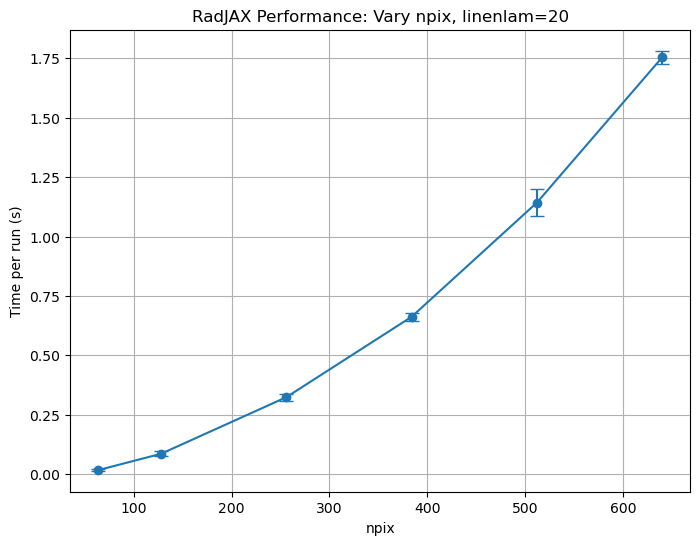

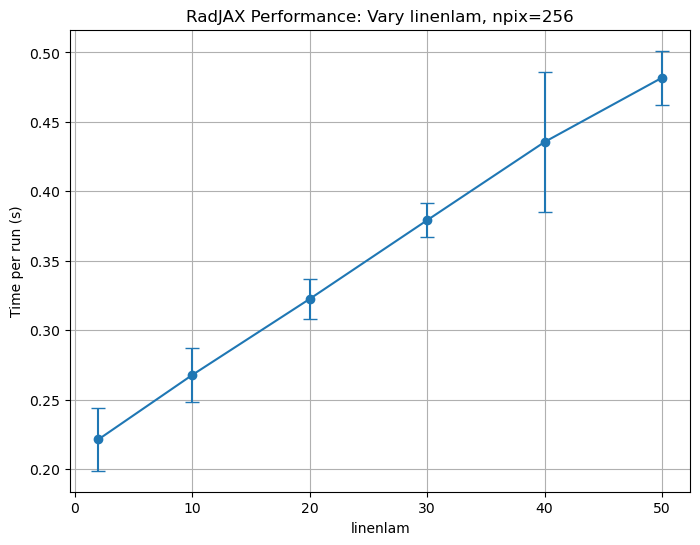

In [43]:
import pandas as pd

# --- Load Stage 1 CSV ---
stage1_df = pd.read_csv("timing_radjax_stage1_results.csv")

# Extract only the numeric rows (excluding 'Avg' and 'Std')
times_stage1 = stage1_df[~stage1_df['Run'].isin(['Avg', 'Std'])].drop(columns='Run').values.astype(float)

# If not already saved, recompute mean and std
avg_stage1 = times_stage1.mean(axis=0)
std_stage1 = times_stage1.std(axis=0)

# --- Load Stage 2 CSV ---
stage2_df = pd.read_csv("timing_radjax_stage2_results.csv")

# Extract only the numeric rows (excluding 'Avg' and 'Std')
times_stage2 = stage2_df[~stage2_df['Run'].isin(['Avg', 'Std'])].drop(columns='Run').values.astype(float)

avg_stage2 = times_stage2.mean(axis=0)
std_stage2 = times_stage2.std(axis=0)

avg_stage1 = times_stage1.mean(axis=0)
avg_stage2 = times_stage2.mean(axis=0)

# Compute std if not already done
std_stage1 = times_stage1.std(axis=0)
std_stage2 = times_stage2.std(axis=0)

# === Plot Stage 1 ===
plt.figure(figsize=(8,6))
plt.errorbar(npix_values, avg_stage1, yerr=std_stage1, fmt='o-', capsize=5)
plt.xlabel('npix')
plt.ylabel('Time per run (s)')
plt.title(f'RadJAX Performance: Vary npix, linenlam={20}')
plt.grid(True)
plt.savefig('stage1_vary_npix.png', dpi=150)
plt.show()

# === Plot Stage 2 ===
plt.figure(figsize=(8,6))
plt.errorbar(linenlam_values, avg_stage2, yerr=std_stage2, fmt='o-', capsize=5)
plt.xlabel('linenlam')
plt.ylabel('Time per run (s)')
plt.title(f'RadJAX Performance: Vary linenlam, npix={256}')
plt.grid(True)
plt.savefig('stage2_vary_linenlam.png', dpi=150)
plt.show()

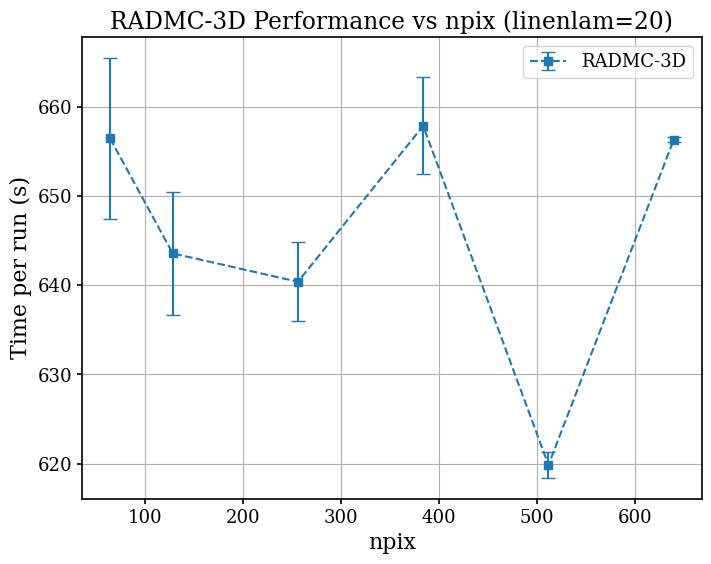

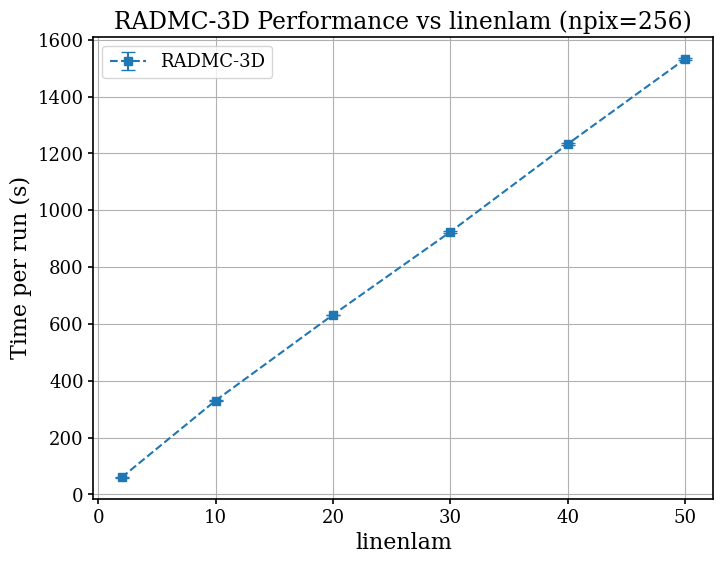

In [132]:
# === RADMC3D data ===

# Stage 1 (Vary npix, linenlam=20)
radmc3d_stage1_times = np.array([
    [667.78, 650.67, 642.68, 656.16, 620.65, 656.34],
    [655.88, 645.82, 634.19, 665.17, 617.85, 656.59],
    [645.66, 634.19, 644.27, 652.20, 621.04, 655.91],
])

# Stage 2 (Vary linenlam, npix=256)
radmc3d_stage2_times = np.array([
    [59.51, 327.85, 631.30, 927.39, 1236.14, 1531.04],
    [60.78, 331.25, 633.04, 920.75, 1228.79, 1528.24],
    [58.82, 331.42, 631.89, 923.70, 1234.83, 1538.27],
])

# === Compute mean and std ===
radmc3d_stage1_avg = radmc3d_stage1_times.mean(axis=0)
radmc3d_stage1_std = radmc3d_stage1_times.std(axis=0)

radmc3d_stage2_avg = radmc3d_stage2_times.mean(axis=0)
radmc3d_stage2_std = radmc3d_stage2_times.std(axis=0)

# Speedup factor:
speedup_stage1 = radmc3d_stage1_avg / avg_stage1
speedup_stage2 = radmc3d_stage2_avg / avg_stage2

# Error bars:
speedup_stage1_std = speedup_stage1 * np.sqrt( (std_stage1 / avg_stage1)**2 + (radmc3d_stage1_std / radmc3d_stage1_avg)**2 )
speedup_stage2_std = speedup_stage2 * np.sqrt( (std_stage2 / avg_stage2)**2 + (radmc3d_stage2_std / radmc3d_stage2_avg)**2 )

# === Plot Stage 1 ===
plt.figure(figsize=(8,6))
# plt.errorbar(npix_values, avg_stage1, yerr=std_stage1, fmt='o-', capsize=5, label='RadJAX')
plt.errorbar(npix_values, radmc3d_stage1_avg, yerr=radmc3d_stage1_std, fmt='s--', capsize=5, label='RADMC-3D')
plt.xlabel('npix')
plt.ylabel('Time per run (s)')
plt.title(f'RADMC-3D Performance vs npix (linenlam=20)')
plt.legend()
plt.grid(True)
plt.savefig('compare_stage1_vary_npix.png', dpi=150)
plt.show()

# === Plot Stage 2 ===
plt.figure(figsize=(8,6))
# plt.errorbar(linenlam_values, avg_stage2, yerr=std_stage2, fmt='o-', capsize=5, label='RadJAX')
plt.errorbar(linenlam_values, radmc3d_stage2_avg, yerr=radmc3d_stage2_std, fmt='s--', capsize=5, label='RADMC-3D')
plt.xlabel('linenlam')
plt.ylabel('Time per run (s)')
plt.title(f'RADMC-3D Performance vs linenlam (npix=256)')
plt.legend()
plt.grid(True)
plt.savefig('compare_stage2_vary_linenlam.png', dpi=150)
plt.show()


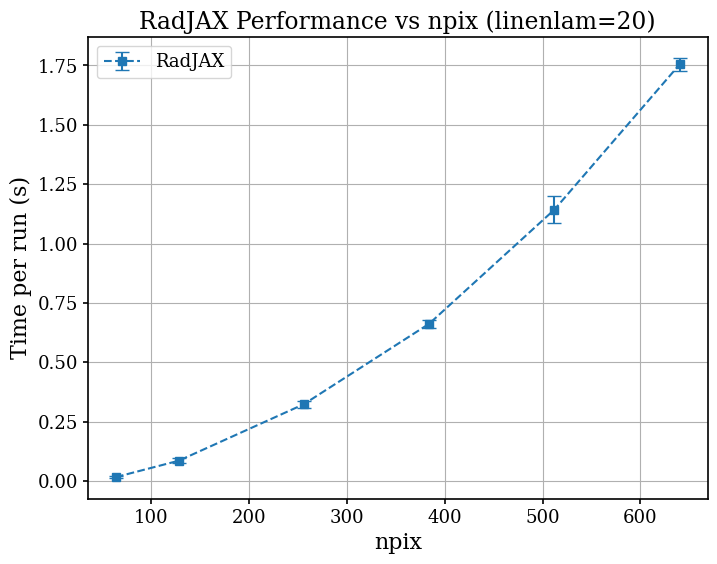

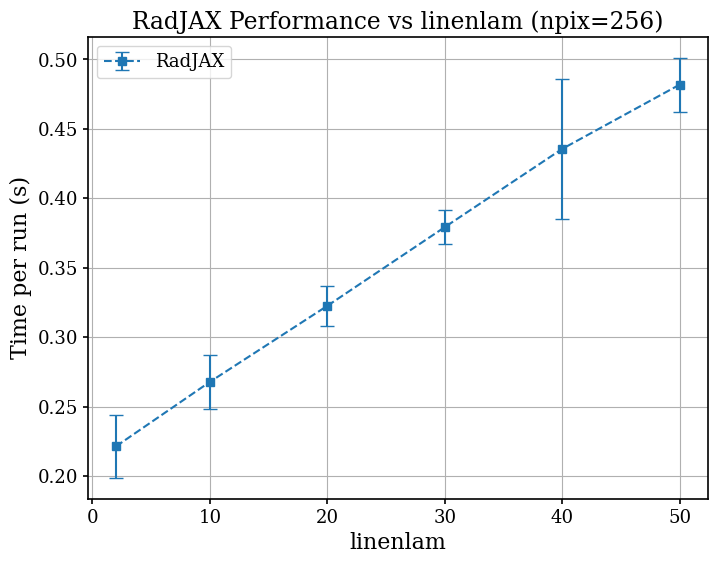

In [133]:
# === RADMC3D data ===

# Stage 1 (Vary npix, linenlam=20)
radmc3d_stage1_times = np.array([
    [667.78, 650.67, 642.68, 656.16, 620.65, 656.34],
    [655.88, 645.82, 634.19, 665.17, 617.85, 656.59],
    [645.66, 634.19, 644.27, 652.20, 621.04, 655.91],
])

# Stage 2 (Vary linenlam, npix=256)
radmc3d_stage2_times = np.array([
    [89.79, 327.85, 631.30, 927.39, 1236.14, 1531.04],
    [89.52, 331.25, 633.04, 920.75, 1228.79, 1528.24],
    [88.82, 331.42, 631.89, 923.70, 1234.83, 1538.27],
])

# === Compute mean and std ===
radmc3d_stage1_avg = radmc3d_stage1_times.mean(axis=0)
radmc3d_stage1_std = radmc3d_stage1_times.std(axis=0)

radmc3d_stage2_avg = radmc3d_stage2_times.mean(axis=0)
radmc3d_stage2_std = radmc3d_stage2_times.std(axis=0)

# Speedup factor:
speedup_stage1 = radmc3d_stage1_avg / avg_stage1
speedup_stage2 = radmc3d_stage2_avg / avg_stage2

# Error bars:
speedup_stage1_std = speedup_stage1 * np.sqrt( (std_stage1 / avg_stage1)**2 + (radmc3d_stage1_std / radmc3d_stage1_avg)**2 )
speedup_stage2_std = speedup_stage2 * np.sqrt( (std_stage2 / avg_stage2)**2 + (radmc3d_stage2_std / radmc3d_stage2_avg)**2 )

# === Plot Stage 1 ===
plt.figure(figsize=(8,6))
# plt.errorbar(npix_values, avg_stage1, yerr=std_stage1, fmt='o-', capsize=5, label='RadJAX')
plt.errorbar(npix_values, avg_stage1, yerr=std_stage1, fmt='s--', capsize=5, label='RadJAX')
plt.xlabel('npix')
plt.ylabel('Time per run (s)')
plt.title(f'RadJAX Performance vs npix (linenlam=20)')
plt.legend()
plt.grid(True)
plt.savefig('compare_stage1_vary_npix.png', dpi=150)
plt.show()

# === Plot Stage 2 ===
plt.figure(figsize=(8,6))
# plt.errorbar(linenlam_values, avg_stage2, yerr=std_stage2, fmt='o-', capsize=5, label='RadJAX')
plt.errorbar(linenlam_values, avg_stage2, yerr=std_stage2, fmt='s--', capsize=5, label='RadJAX')
plt.xlabel('linenlam')
plt.ylabel('Time per run (s)')
plt.title(f'RadJAX Performance vs linenlam (npix=256)')
plt.legend()
plt.grid(True)
plt.savefig('compare_stage2_vary_linenlam.png', dpi=150)
plt.show()


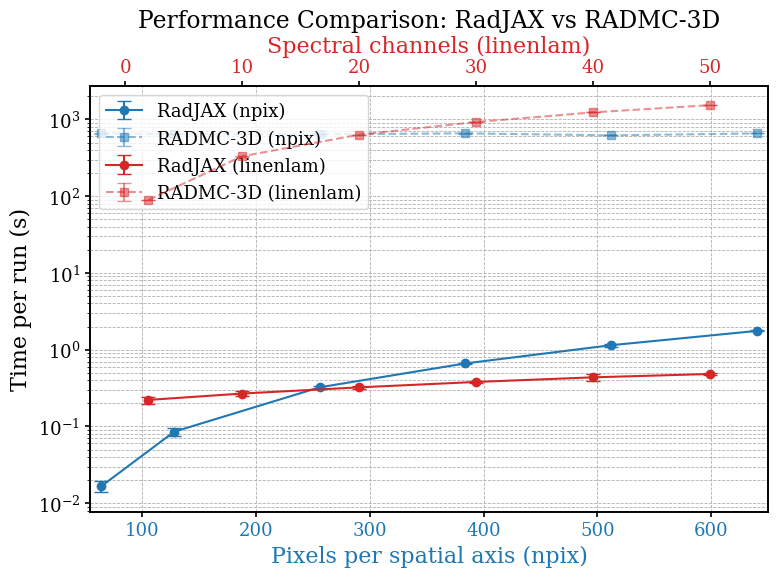

In [136]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 6))

# First axis: npix
color1 = '#1f77b4'
ax1.errorbar(npix_values, avg_stage1, yerr=std_stage1, fmt='o-', capsize=5, label='RadJAX (npix)', color=color1)
ax1.errorbar(npix_values, radmc3d_stage1_avg, yerr=radmc3d_stage1_std, fmt='s--', capsize=5, label='RADMC-3D (npix)', color=color1, alpha=0.5)
ax1.set_xlabel('Pixels per spatial axis (npix)', color=color1)
ax1.tick_params(axis='x', labelcolor=color1)
ax1.set_ylabel('Time per run (s)')
ax1.set_yscale('log')
ax1.grid(True, which='both', linestyle='--', linewidth=0.6)

# Second x-axis for linenlam
ax2 = ax1.twiny()
color2 = '#d62728'
ax2.errorbar(linenlam_values, avg_stage2, yerr=std_stage2, fmt='o-', capsize=5, label='RadJAX (linenlam)', color=color2)
ax2.errorbar(linenlam_values, radmc3d_stage2_avg, yerr=radmc3d_stage2_std, fmt='s--', capsize=5, label='RADMC-3D (linenlam)', color=color2, alpha=0.5)
ax2.set_xlabel('Spectral channels (linenlam)', color=color2)
ax2.tick_params(axis='x', labelcolor=color2)

# Align the x-axis scales manually for clarity
ax1.set_xlim(min(npix_values) - 10, max(npix_values) + 10)
ax2.set_xlim(min(linenlam_values) - 5, max(linenlam_values) + 5)

# Combine both legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Performance Comparison: RadJAX vs RADMC-3D')
plt.tight_layout()
# plt.savefig('combined_dual_x_logplot.png', dpi=300)
plt.show()


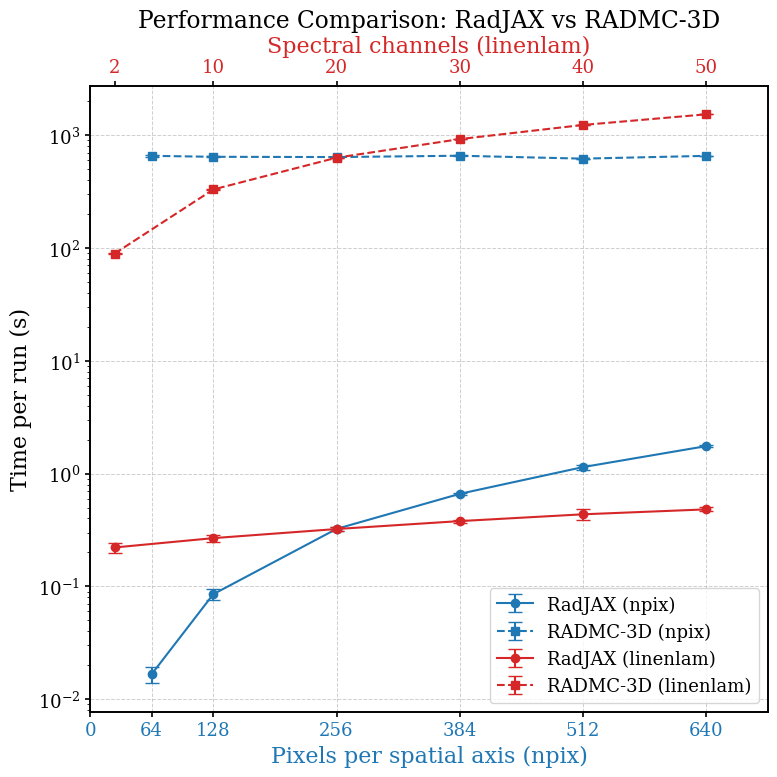

In [143]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# First axis: npix
color1 = '#1f77b4'
ax1.errorbar(npix_values, avg_stage1, yerr=std_stage1, fmt='o-', capsize=5, label='RadJAX (npix)', color=color1)
ax1.errorbar(npix_values, radmc3d_stage1_avg, yerr=radmc3d_stage1_std, fmt='s--', capsize=5, label='RADMC-3D (npix)', color=color1)
ax1.set_xlabel('Pixels per spatial axis (npix)', color=color1)
ax1.set_xticks([0] + npix_values)
ax1.set_xticklabels(['0']+[str(n) for n in npix_values])
ax1.tick_params(axis='x', labelcolor=color1)
ax1.set_ylabel('Time per run (s)')
ax1.set_yscale('log')

# Second x-axis for linenlam
ax2 = ax1.twiny()
color2 = '#d62728'
ax2.errorbar(linenlam_values, avg_stage2, yerr=std_stage2, fmt='o-', capsize=5, label='RadJAX (linenlam)', color=color2)
ax2.errorbar(linenlam_values, radmc3d_stage2_avg, yerr=radmc3d_stage2_std, fmt='s--', capsize=5, label='RADMC-3D (linenlam)', color=color2)
ax2.set_xticks(linenlam_values)
ax2.set_xlabel('Spectral channels (linenlam)', color=color2)
ax2.tick_params(axis='x', labelcolor=color2)

# Axis limits
ax1.set_xlim(min(npix_values) - 64, max(npix_values) + 64)
ax2.set_xlim(min(linenlam_values) - 2, max(linenlam_values) + 5)
ax1.grid(True, linestyle='--', linewidth=0.7, alpha=0.6, zorder=0)
# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Performance Comparison: RadJAX vs RADMC-3D')
plt.tight_layout()
plt.savefig(f'{figures_dir}runtime_combined.svg', format='svg', dpi=400, bbox_inches='tight')
plt.show()


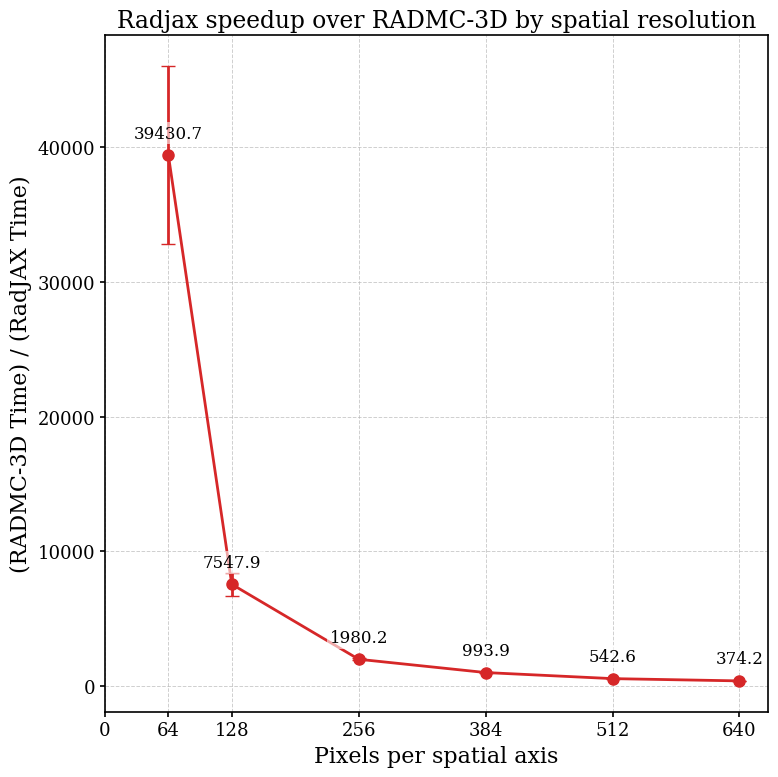

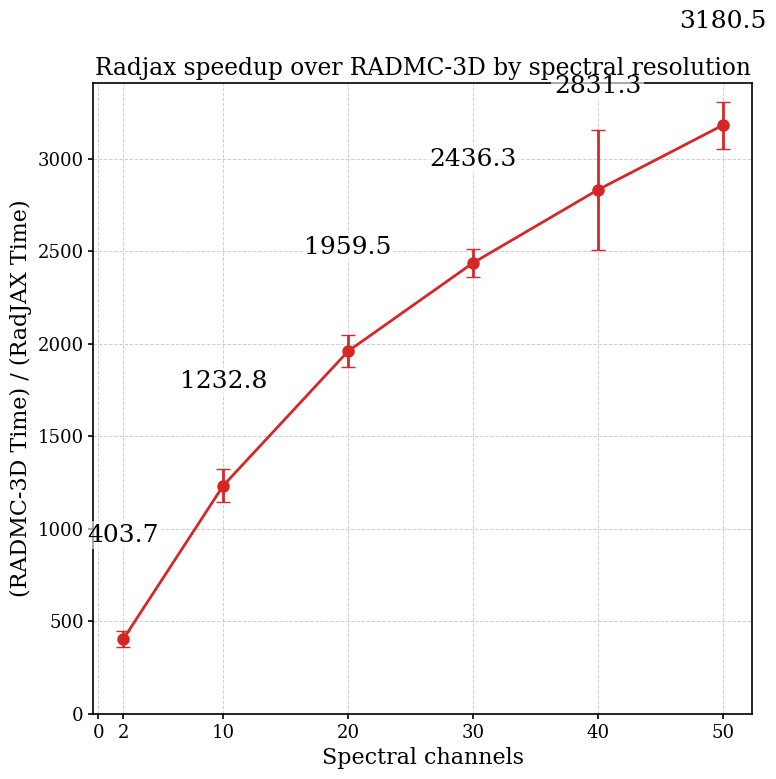

In [145]:
from importlib import reload 

import matplotlib.pyplot as plt
import matplotlib as mpl
reload(mpl)

# General style settings (CVPR style with sans-serif Arial)
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "text.usetex": False  # keep False, you're not using full LaTeX here
})
# Line and marker style
line_style = dict(fmt='o-', capsize=5, markersize=8, linewidth=2, color='#D62728')  # red tone

# --- Plot speedup Stage 1 ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.errorbar(npix_values, speedup_stage1, yerr=speedup_stage1_std, **line_style)

ax.set_xlabel('Pixels per spatial axis')
ax.set_ylabel('(RADMC-3D Time) / (RadJAX Time)')

# Force x-axis to match npix_values exactly
ax.set_xticks([0] + npix_values)
ax.set_xticklabels(['0']+[str(n) for n in npix_values])

# Add value labels (1 decimal place), positioned higher above point
for x, y in zip(npix_values, speedup_stage1):
    label = f"{y:.1f}"
    ax.text(x, y + 1000, label,
            ha='center', va='bottom', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

# Grid: subtle, behind content
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6, zorder=0)
ax.set_title("Radjax speedup over RADMC-3D by spatial resolution")

# Tweak spines to match CVPR style (you can keep or comment out as you prefer)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('speedup_stage1_cvpr.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot speedup Stage 2 ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.errorbar(linenlam_values, speedup_stage2, yerr=speedup_stage2_std, **line_style)

ax.set_xlabel('Spectral channels')
ax.set_ylabel('(RADMC-3D Time) / (RadJAX Time)')

ax.set_xticks([0] + linenlam_values)
ax.set_xticklabels(['0']+[str(n) for n in linenlam_values])

# Add value labels (1 decimal place), positioned higher above point
for x, y in zip(linenlam_values, speedup_stage2):
    label = f"{y:.1f}"
    ax.text(x, y + 500, label,
            ha='center', va='bottom', fontsize=18,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

# Grid: subtle, behind content
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6, zorder=0)
ax.set_title("Radjax speedup over RADMC-3D by spectral resolution")

ax.set_ylim(0, max(speedup_stage2 + speedup_stage2_std) + 100)
# Tweak spines to match CVPR style
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{figures_dir}speedup_spectral.svg', format='svg', dpi=400, bbox_inches='tight')
plt.show()
